# Explore LOF anomalies

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [8]:
import joblib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import umap

from sdss.metadata import MetaData

meta = MetaData()

# Custom Functions

## Scale data

In [3]:
def standard_scaler(latent_arr):

    scaler = StandardScaler()
    
    latent_scaled = scaler.fit_transform(latent_arr)
    
    return latent_scaled

## Score to df

# Config

## Directories

In [4]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
ch4_dir = f"{thesis_dir}/chapters/04_figures"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
bins_ids = [f'bin_{i:02d}' for i in range(4)] 

## Data

In [5]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave*0.1
n_wave = wave.shape

spectra = np.load(
    f"{spectra_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(
    f"{spectra_dir}/ids_imputing.npy",
    mmap_mode='r'
)

## Scaled latent per bin

In [6]:
latent_bin_dict = {}
scaled_latent_bin_dict = {}

for bin_id in bins_ids:

    latent = np.load(
        f"{latent_dir}/{bin_id}/latent_{bin_id}.npy"
    )
    scaled_latent = standard_scaler(latent)

    latent_bin_dict[bin_id] = latent
    scaled_latent_bin_dict[bin_id] = scaled_latent 

## LOF models per bin
The consensus-based strategy made LOF models winners to have
```python
n=60 and metric='manhattan'
```

In [10]:
n = 60
metric = 'manhattan'
lof_model_dict = {}
neg_outlier_factor_dict = {}

for bin_id in bins_ids:
    load_from = os.path.join(
        latent_dir, bin_id,
        f'lof_{bin_id}_n{n}_{metric}.joblib'
    )

    model = joblib.load(load_from)
    lof_model_dict[bin_id] = model
  
    raw_score = model.negative_outlier_factor_
    neg_outlier_factor_dict[bin_id] = raw_score
    
    np.save(
       f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
       raw_score
    )

# LOF scores

In [13]:
# build dataframe with score
def score_arr_to_df(score_path, bin_idx_to_specobjid):

    score_name = score_path.split("/")[-1][:-4]
    objids_bin = bin_idx_to_specobjid[:, 1]

    print(f"Loading score: {score_name}")
    raw_score = {'raw_score': np.load(score_path)}

    score_df = pd.DataFrame(data=raw_score, index=objids_bin)
    score_df.index.name = 'specobjid'

    return score_df

bin_id = 'bin_03'
bin_idx_to_specobjid = np.load(
    f"{spectra_dir}/"
    f"{bin_id}/{bin_id}_index_specobjid.npy"
)
score_df = score_arr_to_df(
    f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
    bin_idx_to_specobjid
)
score_df.sort_values('raw_score', ascending=True)

Loading score: neg_outlier_factor_bin_03_n60_manhattan


,raw_score
specobjid,
969534273977608192,-3.056807
2930814289679771648,-2.913354
2245159102839810048,-2.851112
1071977423131666432,-2.731193
1919783100783552512,-2.624299
...,...
1991763448324712448,-0.955587
1911853960902240256,-0.955120
731886652447811584,-0.954817


In [14]:
bin_id = 'bin_02'
bin_idx_to_specobjid = np.load(
    f"{spectra_dir}/"
    f"{bin_id}/{bin_id}_index_specobjid.npy"
)
score_df = score_arr_to_df(
    f"{latent_dir}/{bin_id}/neg_outlier_factor_{bin_id}_n{n}_{metric}.npy",
    bin_idx_to_specobjid
)
score_df.sort_values('raw_score', ascending=True)

Loading score: neg_outlier_factor_bin_02_n60_manhattan


,raw_score
specobjid,
1645099794210777088,-4.299020
1648419220301572096,-3.983472
1424436875497596928,-3.843307
412203369680103424,-3.724403
3242655029273847808,-3.485241
...,...
394217278125664256,-0.955624
2424199734173394944,-0.955484
1820601367174080512,-0.955009


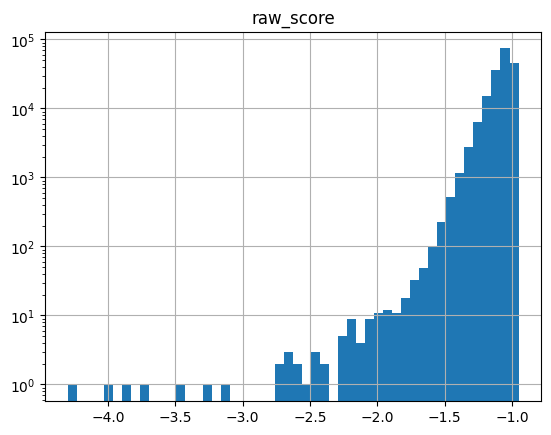

In [16]:
score_df.hist(bins=50)
plt.yscale('log')